## The `extent` parameter in `geomImshow()` 

A list of four numbers: `[left, right, bottom, top]` that
defines the image bounding box
in terms of 'data coordinates'.

In [1]:
%useLatestDescriptors
%use lets-plot
@file:DependsOn("org.apache.commons:commons-math3:3.6.1")

The default `extent` is derived from the image's array dimentions: `[-0.5, ncol-0.5, -0.5, nrow-0.5]`.


In [2]:
// An 2x2 pix image by default has extent [-0.5, 1.5, -0.5, 1.5]
val arr = RasterData.create(
    listOf(
        listOf(
            listOf(150, 0, 0), listOf(0, 150, 0)
        ),
        listOf(
            listOf(0, 0, 150), listOf(150, 150, 0)
        )
    )
)

letsPlot() + geomImshow(arr)

-0.5 
 
 
 
 
 
 
 
 
 0 
 
 
 
 
 
 
 
 
 0.5 
 
 
 
 
 
 
 
 
 1 
 
 
 
 
 
 
 
 
 1.5 
 
 
 
 
 
 
 
 
 
 
 -0.5 
 
 
 
 
 
 
 0 
 
 
 
 
 
 
 0.5 
 
 
 
 
 
 
 1 
 
 
 
 
 
 
 1.5 
 
 
 
 
 
 
 
 
 y 
 
 
 
 
 x

## When does image `extent` need to be set explicitly

Let's assume that our image doesn't exist in vacuum but is related to some data, 
and the image' bounding box in the 'data coordinates' is: 

- `(x, y) = (0, -1)`
- `(width, height) = (8, 3)`.

The image `extent` in this case would be: `[0, 8, -1, 3]`.

In [3]:
import org.apache.commons.math3.distribution.MultivariateNormalDistribution

In [4]:
val cov0 : Array<DoubleArray> = arrayOf(doubleArrayOf(1.0, -.8),
                                        doubleArrayOf(-.8, 1.0))

val cov1 : Array<DoubleArray> = arrayOf(doubleArrayOf(10.0, .1),
                                        doubleArrayOf(.1, 0.1))

val n = 400

val means0 : DoubleArray = doubleArrayOf(4.0, 0.0)
val means1 : DoubleArray = doubleArrayOf(4.0, 1.0)

val xy0 = MultivariateNormalDistribution(means0, cov0).sample(n)
val xy1 = MultivariateNormalDistribution(means1, cov1).sample(n)

val data = mapOf(
    "x" to (xy0.map { it[0] } + xy1.map { it[0] }).toList(),
    "y" to (xy0.map { it[1] } + xy1.map { it[1] }).toList()
)

In [5]:
letsPlot(data) { x = "x"; y = "y" } + geomDensity2D() + ggsize(620, 300)

<path d="M529.0086233383474 54.414143043852526 L529.0086233383474 54.414143043852526 L529.8546746107684 54.682168945062884 L531.7241216837823 55.526221177783505 L534.027489370048 56.56618784302571 L534.2499945654705 56.70778617523629 L534.3781178982613 56.78932157581874 L534.4912041984369 56.959246481243575 L535.7002000899337 58.28352160407273 L536.2597946676251 58.896474206574595 L536.307592702656 59.732001387144614 L536.3675107090539 60.146143141792436 L536.4915714031971 61.00362683733045 L536.0113853097978 61.730610986416096 L535.4421717453979 62.59237946420306 L535.1604223087375 63.11077946808631 L534.7811678031502 63.386959414521485 L534.027489370048 63.93580159363087 L532.7108913794993 64.7354743999935 L531.916562959457 65.21793209884217 L530.2012334781134 65.9229812583178 L528.2771968033564 66.71381500489058 L527.3680829450101 66.99194660904953 L526.2791722365348 67.32508472959802 L524.2013452071853 67.938671369783 L522.5269042366651 68.43313726842483 L520.84310233652 68.81522047601052 L518.1239715774274 69.43223736035387 L517.388235839561 69.65636256146884 L516.7766116699738 69.8426799889912 L513.9051163984408 70.48715156229264 L513.8862735970637 70.49138059584504 L511.0263191032824 71.03613470696907 L509.4657248757554 70.9675216567707 L506.5771523420467 71.06260196126382 L505.2760265365911 71.06260196126382 L503.2076000310824 70.19019711667204 L501.41051687663145 69.43223736035387 L500.60092541902935 69.0382413220091 L499.52573396989965 68.51498830662527 L498.53096951744544 67.68960888357118 L498.09163742325336 67.32508472959802 L497.6729300352721 66.64613828646571 L497.12109084376004 66.0990959753768 L496.23220025639654 65.21793209884217 L495.94118439791146 64.42431142721507 L495.7209415656956 63.82369376557219 L495.2484385376219 63.11077946808631 L495.1919084733564 62.59172547585456 L495.07063928322754 61.478242622280355 L494.96561092483785 61.00362683733045 L495.1001414114179 60.518200213400014 L495.2406644597289 59.43339447321904 L495.31021578101553 58.896474206574595 L495.9039586844055 58.11649462524613 L496.08518072389774 57.63570864734671 L496.40420831278925 56.78932157581874 L497.39534516318025 56.0086561876584 L498.69120702339166 54.987975237590845 L498.899918630177 54.682168945062884 L499.16254677669815 54.54908165589703 L499.52573396989965 54.36503588759985 L501.5838364525413 53.92799235137373 L502.52535757356037 53.67420643279657 L505.2760265365911 52.932766826291775 L506.11233175048136 52.881474239903994 L511.0096975659452 52.5811071550288 L511.0263191032824 52.57900693637218 L511.03720927045055 52.57900693637218 L516.5224322003011 52.66815852089793 L516.7766116699738 52.667672400401116 L517.1100382973851 52.69719806192516 L521.2747297603994 53.0338664877943 L522.5269042366651 53.135090699379184 L525.2846453833845 53.671614882837666 L525.785222427399 53.76900317111755 L528.2771968033564 54.18242983379009 L529.0086233383474 54.414143043852526 " fill="none" stroke-width="1.1" stroke="rgb(71,71,71)" stroke-opacity="1.0">
 
 
 
 <path d="M229.79258993615213 10.237526793294563 L229.79258993615213 10.237526793294563 L230.03247755327095 10.431963699189936 L230.33001883704944 10.823337492945555 L231.1385546569823 11.851460501794094 L231.67934050075885 12.539116329945784 L232.1522355342022 13.587157193150759 L232.15822051742845 13.600421250802171 L232.7556022284631 14.646268960701647 L233.19757161038825 15.31125406849712 L233.8804170574902 16.338660200729066 L234.2444286227983 16.753421591457496 L234.5299430537686 16.930168934043337 L235.0122759020964 17.228756465658037 L236.26509074860274 18.401489389737648 L236.75552491491806 18.86057422221336 L238.60955404533314 19.649530602053375 L240.76256846878778 20.565716026222944 L241.27611908303385 20.779539988512397 L241.7280959279115 20.967726852969193 L244.73919646953863 21.61767325358346 L246.51286103547912 22.00051895554303 L248.39111028029157 22.386608792882825 L251.7394084748469 23.07487948372507 L252.12221689183175 23.126524709862025 L252.26315360217052 23.145538

Let's show the data and the image on the same plot.

In [6]:
letsPlot(data) {x="x"; y="y"} + 
 geomImshow(arr, extent=listOf(0.0, 8.0, -1.0, 3.0)) + 
 geomDensity2D(color="yellow") + 
 ggsize(620, 300) + flavorHighContrastDark()

<path d="M529.0086233383474 75.20314193615582 L529.0086233383474 75.20314193615582 L529.8546746107684 75.47116783736618 L531.7241216837823 76.31522007008681 L534.027489370048 77.355186735329 L534.2499945654705 77.49678506753958 L534.3781178982613 77.57832046812203 L534.4912041984369 77.74824537354687 L535.7002000899337 79.07252049637603 L536.2597946676251 79.68547309887788 L536.307592702656 80.5210002794479 L536.3675107090539 80.93514203409572 L536.4915714031971 81.79262572963374 L536.0113853097978 82.5196098787194 L535.4421717453979 83.38137835650636 L535.1604223087375 83.89977836038959 L534.7811678031502 84.17595830682478 L534.027489370048 84.72480048593417 L532.7108913794993 85.5244732922968 L531.916562959457 86.00693099114545 L530.2012334781134 86.71198015062109 L528.2771968033564 87.50281389719387 L527.3680829450101 87.78094550135283 L526.2791722365348 88.1140836219013 L524.2013452071853 88.72767026208629 L522.5269042366651 89.22213616072811 L520.84310233652 89.60421936831382 L518.1239715774274 90.22123625265716 L517.388235839561 90.44536145377212 L516.7766116699738 90.63167888129448 L513.9051163984408 91.27615045459592 L513.8862735970637 91.28037948814834 L511.0263191032824 91.82513359927236 L509.4657248757554 91.75652054907398 L506.5771523420467 91.8516008535671 L505.2760265365911 91.8516008535671 L503.2076000310824 90.97919600897532 L501.41051687663145 90.22123625265716 L500.60092541902935 89.8272402143124 L499.52573396989965 89.30398719892855 L498.53096951744544 88.47860777587447 L498.09163742325336 88.1140836219013 L497.6729300352721 87.435137178769 L497.12109084376004 86.88809486768008 L496.23220025639654 86.00693099114545 L495.94118439791146 85.21331031951836 L495.7209415656956 84.61269265787547 L495.2484385376219 83.89977836038959 L495.1919084733564 83.38072436815784 L495.07063928322754 82.26724151458365 L494.96561092483785 81.79262572963374 L495.1001414114179 81.3071991057033 L495.2406644597289 80.22239336552232 L495.31021578101553 79.68547309887788 L495.9039586844055 78.90549351754942 L496.08518072389774 78.42470753965 L496.40420831278925 77.57832046812203 L497.39534516318025 76.79765507996169 L498.69120702339166 75.77697412989414 L498.899918630177 75.47116783736618 L499.16254677669815 75.33808054820032 L499.52573396989965 75.15403477990314 L501.5838364525413 74.71699124367703 L502.52535757356037 74.46320532509986 L505.2760265365911 73.72176571859507 L506.11233175048136 73.67047313220729 L511.0096975659452 73.37010604733209 L511.0263191032824 73.36800582867548 L511.03720927045055 73.36800582867548 L516.5224322003011 73.45715741320123 L516.7766116699738 73.45667129270441 L517.1100382973851 73.48619695422846 L521.2747297603994 73.8228653800976 L522.5269042366651 73.92408959168247 L525.2846453833845 74.46061377514096 L525.785222427399 74.55800206342084 L528.2771968033564 74.97142872609338 L529.0086233383474 75.20314193615582 " fill="none" stroke-width="1.1" stroke="rgb(255,255,0)" stroke-opacity="1.0">
 
 
 
 <path d="M229.79258993615213 31.02652568559786 L229.79258993615213 31.02652568559786 L230.03247755327095 31.220962591493233 L230.33001883704944 31.612336385248852 L231.1385546569823 32.64045939409739 L231.67934050075885 33.32811522224908 L232.1522355342022 34.376156085454056 L232.15822051742845 34.38942014310547 L232.7556022284631 35.435267853004945 L233.19757161038825 36.10025296080042 L233.8804170574902 37.127659093032364 L234.2444286227983 37.54242048376079 L234.5299430537686 37.719167826346634 L235.0122759020964 38.017755357961335 L236.26509074860274 39.190488282040945 L236.75552491491806 39.649573114516656 L238.60955404533314 40.43852949435667 L240.76256846878778 41.35471491852624 L241.27611908303385 41.568538880815694 L241.7280959279115 41.756725745272504 L244.73919646953863 42.40667214588676 L246.51286103547912 42.78951784784633 L248.39111028029157 43.17560768518612 L251.7394084748469 43.86387837602837 L252.12221689183175 43.91552360216532 L252.26315360217052 43.93453757352407 L252.6165242964295 43.9933

### Flipping and transposing image using `extent`

In [7]:
@file:DependsOn("com.github.jai-imageio:jai-imageio-core:1.3.0")
import javax.imageio.ImageIO
import java.net.URL
import org.jetbrains.letsPlot.geom.Extensions.create

val img = ImageIO.read(
    URL("https://github.com/JetBrains/lets-plot-docs/raw/master/source/examples/cookbook/images/fisher_boat.png")
)
val fisherBoat = RasterData.create(img)
fisherBoat

RasterData(225 x 225 x 3)

<path d="M201.391473127781 39.320826528799785 C201.391473127781 39.320826528799785 204.54147312778102 39.320826528799785 204.54147312778102 36.170826528799786 L204.54147312778102 21.470826528799783 C204.54147312778102 21.470826528799783 204.54147312778102 18.320826528799785 201.391473127781 18.320826528799785 L144.45844521781643 18.320826528799785 C144.45844521781643 18.320826528799785 141.30844521781643 18.320826528799785 141.30844521781643 21.470826528799783 L141.30844521781643 36.170826528799786 C141.30844521781643 36.170826528799786 141.30844521781643 39.320826528799785 144.45844521781643 39.320826528799785 Z" stroke="rgb(71,71,71)" stroke-opacity="1.0" fill="rgb(255,255,255)" fill-opacity="1.0" stroke-width="1.0">
 
 
 
 original 
 
 
 
 
 <path d="M507.0459895605976 39.320826528799785 C507.0459895605976 39.320826528799785 510.1959895605976 39.320826528799785 510.1959895605976 36.170826528799786 L510.1959895605976 21.470826528799783 C510.1959895605976 21.470826528799783 510.1959895605976 18.320826528799785 507.0459895605976 18.320826528799785 L415.2204593609956 18.320826528799785 C415.2204593609956 18.320826528799785 412.07045936099564 18.320826528799785 412.07045936099564 21.470826528799783 L412.07045936099564 36.170826528799786 C412.07045936099564 36.170826528799786 412.07045936099564 39.320826528799785 415.2204593609956 39.320826528799785 Z" stroke="rgb(71,71,71)" stroke-opacity="1.0" fill="rgb(255,255,255)" fill-opacity="1.0" stroke-width="1.0">
 
 
 
 flip columns 
 
 
 
 
 <path d="M497.0277268953176 615.7373571047956 C497.0277268953176 615.7373571047956 500.17772689531756 615.7373571047956 500.17772689531756 612.5873571047956 L500.17772689531756 597.8873571047956 C500.17772689531756 597.8873571047956 500.17772689531756 594.7373571047956 497.0277268953176 594.7373571047956 L425.2387220262757 594.7373571047956 C425.2387220262757 594.7373571047956 422.0887220262757 594.7373571047956 422.0887220262757 597.8873571047956 L422.0887220262757 612.5873571047956 C422.0887220262757 612.5873571047956 422.0887220262757 615.7373571047956 425.2387220262757 615.7373571047956 Z" stroke="rgb(71,71,71)" stroke-opacity="1.0" fill="rgb(255,255,255)" fill-opacity="1.0" stroke-width="1.0">
 
 
 
 transpose 
 
 
 
 
 <path d="M205.94597699838184 615.7373571047956 C205.94597699838184 615.7373571047956 209.09597699838184 615.7373571047956 209.09597699838184 612.5873571047956 L209.09597699838184 597.8873571047956 C209.09597699838184 597.8873571047956 209.09597699838184 594.7373571047956 205.94597699838184 594.7373571047956 L139.90394134721564 594.7373571047956 C139.90394134721564 594.7373571047956 136.75394134721563 594.7373571047956 136.75394134721563 597.8873571047956 L136.75394134721563 612.5873571047956 C136.75394134721563 612.5873571047956 136.75394134721563 615.7373571047956 139.90394134721564 615.7373571047956 Z" stroke="rgb(71,71,71)" stroke-opacity="1.0" fill="rgb(255,255,255)" fill-opacity="1.0" stroke-width="1.0">
 
 
 
 flip rows 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 0 
 
 
 
 
 
 
 
 
 20 
 
 
 
 
 
 
 
 
 40 
 
 
 
 
 
 
 
 
 60 
 
 
 
 
 
 
 
 
 80 
 
 
 
 
 
 
 
 
 100 
 
 
 
 
 
 
 
 
 120 
 
 
 
 
 
 
 
 
 140 
 
 
 
 
 
 
 
 
 160 
 
 
 
 
 
 
 
 
 180 
 
 
 
 
 
 
 
 
 200 
 
 
 
 
 
 
 
 
 
 
 0 
 
 
 
 
 
 
 20 
 
 
 
 
 
 
 40 
 
 
 
 
 
 
 60 
 
 
 
 
 
 
 80 
 
 
 
 
 
 
 100 
 
 
 
 
 
 
 120 
 
 
 
 
 
 
 140 
 
 
 
 
 
 
 160 
 
 
 
 
 
 
 180 
 
 
 
 
 
 
 200 
 
 
 
 
 
 
 
 
 y 
 
 
 
 
 x
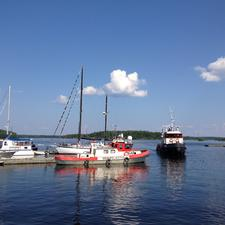
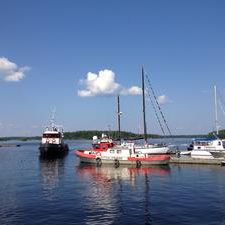
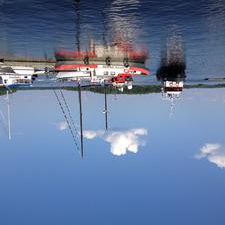
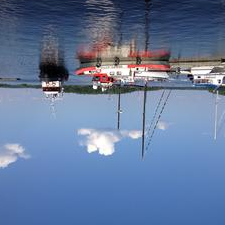
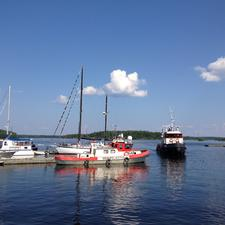
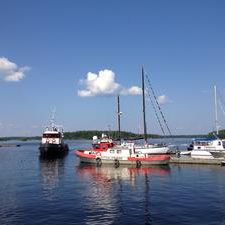
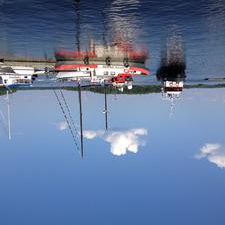
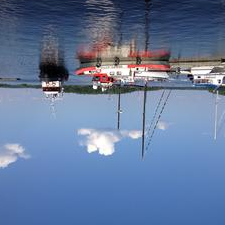

In [8]:
val dim = 100

val ext_base = listOf(0, dim, dim, dim + dim)
val ext_flip_x = listOf(dim + dim, 0 + dim, 0 + dim, dim + dim)
val ext_flip_y = listOf(0, dim, dim, 0)
val ext_transpose = listOf(dim + dim, 0 + dim, dim, 0)

val label_data = mapOf(
    "x" to listOf(50, 150, 150, 50),
    "y" to listOf(200, 200, 0, 0),
    "label" to listOf("original", "flip columns", "transpose", "flip rows")
)

(letsPlot() + 
     geomImshow(fisherBoat, extent=ext_base) + 
     geomImshow(fisherBoat, extent=ext_flip_x) + 
     geomImshow(fisherBoat, extent=ext_flip_y) + 
     geomImshow(fisherBoat, extent=ext_transpose) + 
        
     geomHLine(yintercept=100, color="yellow", tooltips=tooltipsNone) + 
     geomVLine(xintercept=100, color="yellow", tooltips=tooltipsNone) + 
     geomLabel(data=label_data) {x="x"; y="y"; label="label" } +
     ggsize(700, 700)
)